Default tree depth: 5
Default train acc:  1.000
Default test acc:   0.933

Best params: {'max_depth': 4, 'min_samples_leaf': 1}
Best CV accuracy: 0.942
Test accuracy (best): 0.933


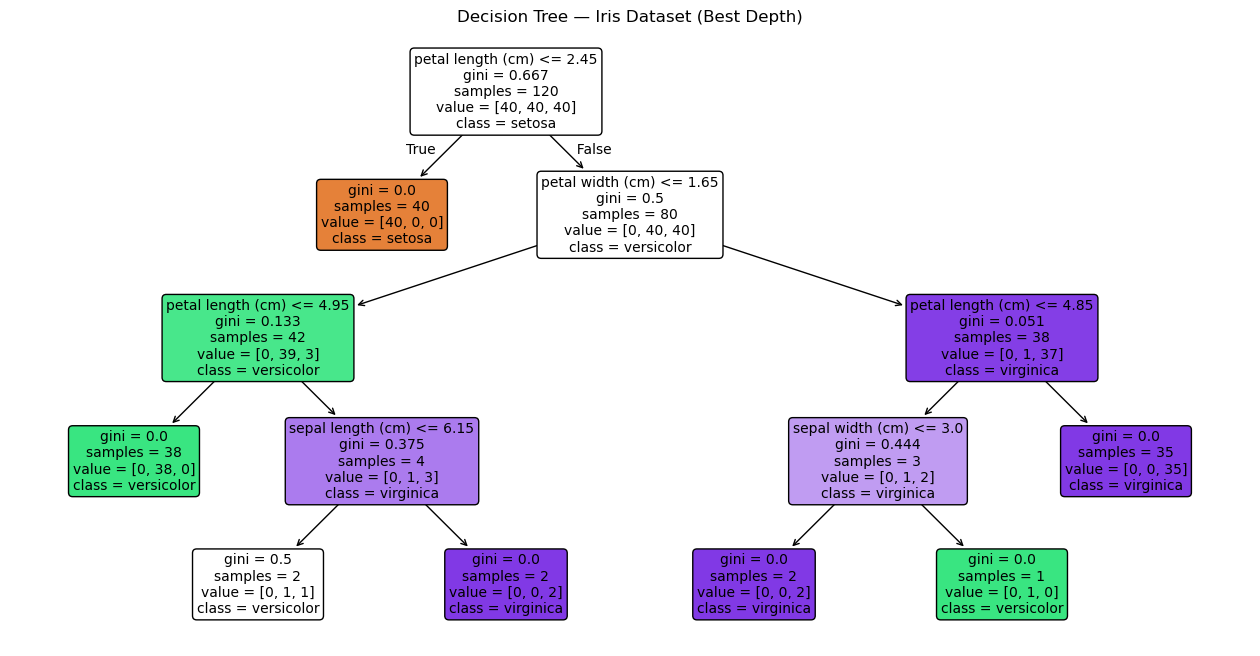

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- sepal length (cm) <= 6.15
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  6.15
|   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2


Feature Importances:
  petal length (cm)              ██████████████████████ (0.566)
  petal width (cm)               ████████████████ (0.411)
  sepal width (cm)                (0.017)
  sepal length (cm)               (0.006)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

# ─── Load data ──────────────────────────────────────────────────────────────
data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ─── Train with default settings (will overfit!) ────────────────────────────
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)
print(f"Default tree depth: {tree_default.get_depth()}")
print(f"Default train acc:  {tree_default.score(X_train, y_train):.3f}")
print(f"Default test acc:   {tree_default.score(X_test, y_test):.3f}")

# ─── Tune max_depth via grid search ─────────────────────────────────────────
param_grid = {'max_depth': [2, 3, 4, 5, 6, 7, None],
              'min_samples_leaf': [1, 2, 5, 10]}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

best_tree = grid_search.best_estimator_
print(f"Test accuracy (best): {best_tree.score(X_test, y_test):.3f}")

# ─── Visualise the tree ──────────────────────────────────────────────────────
plt.figure(figsize=(16, 8))
plot_tree(best_tree,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True,          # colour nodes by class
          rounded=True,         # rounded boxes look nicer
          fontsize=10)
plt.title("Decision Tree — Iris Dataset (Best Depth)")
plt.show()

# ─── Text representation (printable, shareable) ──────────────────────────────
print(export_text(best_tree, feature_names=list(data.feature_names)))

# ─── Feature importance ──────────────────────────────────────────────────────
importances = best_tree.feature_importances_
feat_imp = sorted(zip(data.feature_names, importances), key=lambda x: x[1], reverse=True)
print("\nFeature Importances:")
for feat, imp in feat_imp:
    bar = '█' * int(imp * 40)
    print(f"  {feat:30s} {bar} ({imp:.3f})")

In [5]:
import numpy as np

def bootstrap_sample(X,Y):
  N=len(X)
  indices=np.random.choice(N, size=N, replace=True)
  X_sample = X[indices]
  y_sample = y[indices]
    
  return X_sample, y_sample, indices

In [6]:
# Dummy dataset (just indices for clarity)
X = np.arange(20)
y = np.arange(20)

N = len(X)

unique_props = []
oob_props = []

for i in range(10):
    X_s, y_s, indices = bootstrap_sample(X, y)
    
    unique_indices = np.unique(indices)
    oob_indices = np.setdiff1d(np.arange(N), unique_indices)
    
    unique_prop = len(unique_indices) / N
    oob_prop = len(oob_indices) / N
    
    unique_props.append(unique_prop)
    oob_props.append(oob_prop)
    
    print(f"\nBootstrap {i+1}")
    print("Sampled indices:", indices)
    print("Unique indices:", unique_indices)
    print("OOB indices:", oob_indices)
    print(f"Unique proportion: {unique_prop:.3f}")
    print(f"OOB proportion: {oob_prop:.3f}")


Bootstrap 1
Sampled indices: [ 9 16 13 15 18 13 12 11  2  2 13  8 11 13  3 12 16 15  8  7]
Unique indices: [ 2  3  7  8  9 11 12 13 15 16 18]
OOB indices: [ 0  1  4  5  6 10 14 17 19]
Unique proportion: 0.550
OOB proportion: 0.450

Bootstrap 2
Sampled indices: [ 5  6 12  3 15  4  6  0  6  6 17 18  0 19  0  5  2  2 12 13]
Unique indices: [ 0  2  3  4  5  6 12 13 15 17 18 19]
OOB indices: [ 1  7  8  9 10 11 14 16]
Unique proportion: 0.600
OOB proportion: 0.400

Bootstrap 3
Sampled indices: [ 7 13 18  0  9 15  3 11  2 19  3 16 13  9  8 18 16 19 10  1]
Unique indices: [ 0  1  2  3  7  8  9 10 11 13 15 16 18 19]
OOB indices: [ 4  5  6 12 14 17]
Unique proportion: 0.700
OOB proportion: 0.300

Bootstrap 4
Sampled indices: [11  4 17  0 19 10  9 19  8 19  2 12  8 12  9 18  6 12 10  8]
Unique indices: [ 0  2  4  6  8  9 10 11 12 17 18 19]
OOB indices: [ 1  3  5  7 13 14 15 16]
Unique proportion: 0.600
OOB proportion: 0.400

Bootstrap 5
Sampled indices: [18  1  5  2 15  6 17 17 19  7 14  7 12 12

In [7]:
print("\n--- Summary ---")
print("Average unique proportion:", np.mean(unique_props))
print("Average OOB proportion:", np.mean(oob_props))


--- Summary ---
Average unique proportion: 0.6300000000000001
Average OOB proportion: 0.37
